# Incident Timeline Fusion

Combine synthetic public reports into reliability-weighted incident time windows.

**Safety and scope:** This notebook uses deterministic synthetic data and makes no network requests. Its results are analytical leads, not attribution or identity claims.

## Goal

Create an auditable timeline that highlights corroborated events and visible contradictions.


## Setup

The workflow runs offline with NumPy and Pandas. Parameters and source-like fields are visible so the analysis can be reviewed and rerun.

### Key Assumptions

- All records are synthetic and contain no real people or infrastructure.
- Scores prioritize review; they do not prove ownership, intent, identity, or location.
- Real use requires documented authority, provenance, source terms, and retention limits.


In [1]:
import numpy as np
import pandas as pd

SEED = 88
rng = np.random.default_rng(SEED)
pd.set_option("display.max_columns", 20)
pd.set_option("display.width", 130)
pd.set_option("display.max_colwidth", 70)


## Steps

### 1. Create bounded synthetic observations


In [2]:
observation_count = 160
source_types = np.array(["official", "journalism", "technical-report", "community"])
source_reliability = {"official": 0.90, "journalism": 0.78, "technical-report": 0.86, "community": 0.48}
observations = pd.DataFrame({
    "observation_id": [f"obs-{index:04d}" for index in range(observation_count)],
    "source_type": rng.choice(source_types, observation_count, p=[0.18, 0.32, 0.28, 0.22]),
    "minute": rng.choice([30, 90, 150, 240, 360], observation_count, p=[0.12, 0.24, 0.30, 0.22, 0.12]) + rng.integers(-18, 19, observation_count),
    "event_type": rng.choice(["initial-access", "service-impact", "containment", "recovery"], observation_count),
    "contradiction": rng.binomial(1, 0.10, observation_count),
})
observations["reliability"] = observations["source_type"].map(source_reliability)
observations["time_window"] = (observations["minute"] // 30) * 30
print(observations.head(8).to_string(index=False))


observation_id      source_type  minute     event_type  contradiction  reliability  time_window
      obs-0000       journalism     356       recovery              1         0.78          330
      obs-0001 technical-report      40    containment              0         0.86           30
      obs-0002 technical-report     132       recovery              0         0.86          120
      obs-0003 technical-report     352 initial-access              0         0.86          330
      obs-0004 technical-report      40       recovery              0         0.86           30
      obs-0005         official     152 initial-access              0         0.90          150
      obs-0006         official     103    containment              0         0.90           90
      obs-0007       journalism     102    containment              1         0.78           90


### 2. Analyze and rank the observations


In [3]:
observations["evidence_weight"] = observations["reliability"] * (1 - 0.55 * observations["contradiction"])
timeline = observations.groupby(["time_window", "event_type"], as_index=False).agg(
    reports=("observation_id", "count"),
    source_types=("source_type", "nunique"),
    evidence_weight=("evidence_weight", "sum"),
    contradictions=("contradiction", "sum"),
)
timeline["corroboration_score"] = (
    0.45 * np.minimum(timeline["evidence_weight"] / 8, 1)
    + 0.35 * np.minimum(timeline["source_types"] / 4, 1)
    + 0.20 * (1 - np.minimum(timeline["contradictions"] / timeline["reports"], 1))
).round(3)
ranked_events = timeline.sort_values("corroboration_score", ascending=False)
print(ranked_events.head(10).to_string(index=False))


 time_window     event_type  reports  source_types  evidence_weight  contradictions  corroboration_score
         210    containment        8             4            6.460               0                0.913
         120       recovery       10             3            7.867               1                0.885
         150    containment        9             3            7.300               0                0.873
         150       recovery        7             4            4.760               0                0.818
         120    containment        5             4            3.800               0                0.764
          90    containment        7             4            4.636               2                0.754
         150 service-impact        6             4            3.905               1                0.736
         120 service-impact        6             3            4.240               0                0.701
         120 initial-access        5             3     

## Visual Insights & ML Extension

This section adds a polished visual story and a project-appropriate machine-learning extension while preserving the original transparent score or aggregation. Supervised labels are synthetic evaluation aids; unsupervised clusters and anomalies are review leads only.

**Interpretation boundary:** these results do not prove identity, ownership, intent, attribution, or location. Real use requires lawful authority, source provenance, independent corroboration, and retention controls.


Surrogate model comparison:
                     mae     r2
model                          
Random forest      0.043  0.826
Gradient boosting  0.022  0.958

Analyst takeaways:
- Gradient boosting best reproduces the transparent score (MAE 0.022).
- Strongest score driver in the random-forest surrogate: evidence weight.
- High surrogate accuracy only shows that the heuristic is learnable; it does not validate the heuristic against real outcomes.


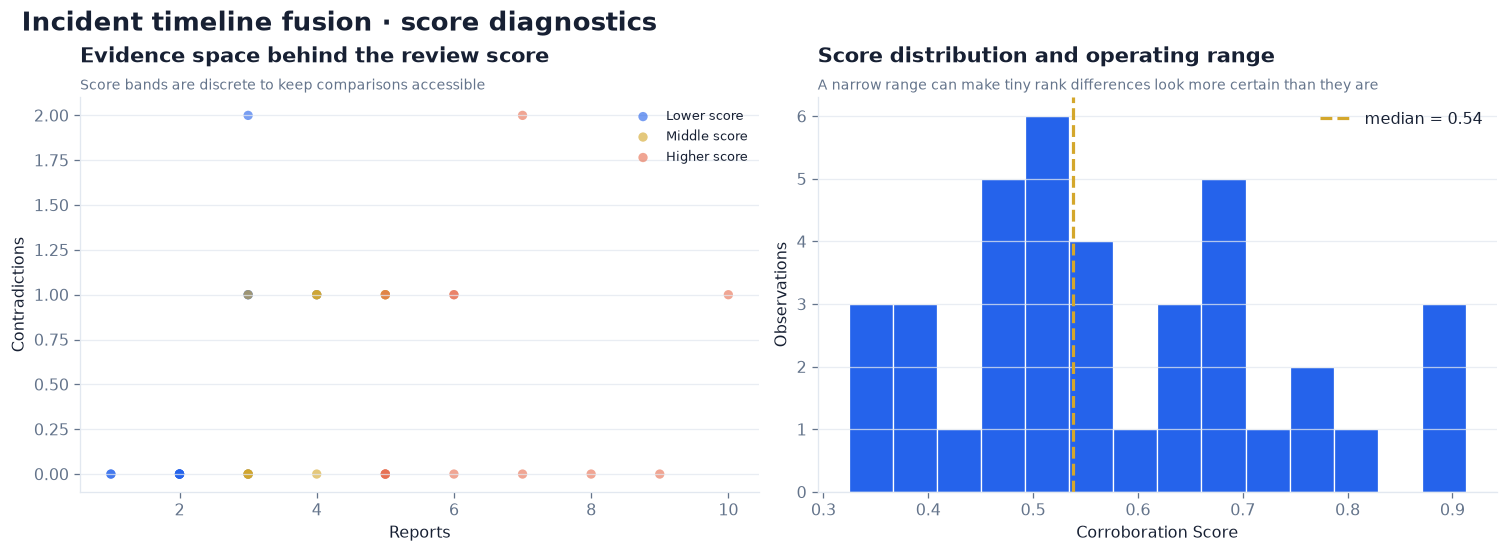

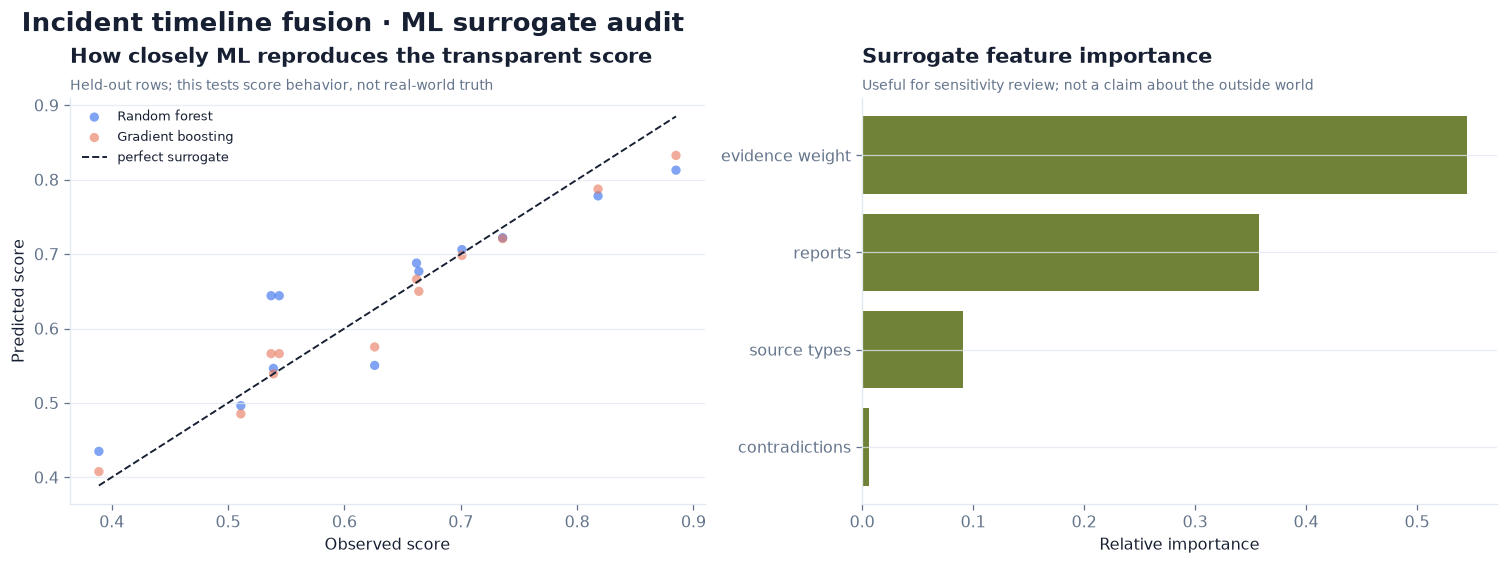

In [4]:
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.ensemble import GradientBoostingRegressor, IsolationForest, RandomForestClassifier, RandomForestRegressor
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import average_precision_score, f1_score, mean_absolute_error, r2_score, roc_auc_score, silhouette_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

SEED = globals().get("SEED", 88)

PALETTE = {
    "blue": "#2563EB",
    "gold": "#D4A72C",
    "orange": "#E76F51",
    "olive": "#708238",
    "pink": "#C65D86",
    "ink": "#172033",
    "muted": "#64748B",
    "grid": "#E2E8F0",
    "paper": "#FFFFFF",
}

plt.rcParams.update({
    "figure.facecolor": PALETTE["paper"],
    "axes.facecolor": PALETTE["paper"],
    "axes.edgecolor": PALETTE["grid"],
    "axes.labelcolor": PALETTE["ink"],
    "axes.titleweight": "bold",
    "axes.titlesize": 13,
    "font.size": 10,
    "text.color": PALETTE["ink"],
    "xtick.color": PALETTE["muted"],
    "ytick.color": PALETTE["muted"],
    "grid.color": PALETTE["grid"],
    "grid.linewidth": 0.8,
})

def polish_axis(ax, title, subtitle, xlabel="", ylabel=""):
    ax.set_title(title, loc="left", pad=22)
    ax.text(0, 1.02, subtitle, transform=ax.transAxes, color=PALETTE["muted"], fontsize=9)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.grid(axis="y", alpha=0.75)
    ax.spines[["top", "right"]].set_visible(False)

def compare_binary_models(features, labels):
    x_train, x_test, y_train, y_test = train_test_split(
        features,
        labels,
        test_size=0.30,
        random_state=SEED,
        stratify=labels,
    )
    models = {
        "Logistic regression": make_pipeline(
            StandardScaler(),
            LogisticRegression(max_iter=1200, class_weight="balanced", random_state=SEED),
        ),
        "Random forest": RandomForestClassifier(
            n_estimators=140,
            min_samples_leaf=2,
            class_weight="balanced",
            random_state=SEED,
            n_jobs=1,
        ),
    }
    rows, probabilities, fitted = [], {}, {}
    for name, model in models.items():
        model.fit(x_train, y_train)
        probability = model.predict_proba(x_test)[:, 1]
        prediction = (probability >= 0.5).astype(int)
        rows.append({
            "model": name,
            "roc_auc": roc_auc_score(y_test, probability),
            "average_precision": average_precision_score(y_test, probability),
            "f1_at_0_5": f1_score(y_test, prediction, zero_division=0),
        })
        probabilities[name] = probability
        fitted[name] = model
    return pd.DataFrame(rows).set_index("model"), fitted, probabilities, y_test

surrogate_frame = timeline.copy()
surrogate_features = surrogate_frame[['reports', 'source_types', 'evidence_weight', 'contradictions']]
surrogate_target = surrogate_frame["corroboration_score"].astype(float)
target_band = pd.qcut(surrogate_target.rank(method="first"), q=3, labels=["Lower", "Middle", "Higher"])

fig, axes = plt.subplots(1, 2, figsize=(13, 4.7), constrained_layout=True)
band_colors = {"Lower": PALETTE["blue"], "Middle": PALETTE["gold"], "Higher": PALETTE["orange"]}
for band in ["Lower", "Middle", "Higher"]:
    subset = surrogate_frame[target_band == band]
    axes[0].scatter(subset["reports"], subset["contradictions"], s=34, alpha=0.62, color=band_colors[band], edgecolors="none", label=f"{band} score")
axes[0].legend(frameon=False, fontsize=8)
polish_axis(axes[0], "Evidence space behind the review score", "Score bands are discrete to keep comparisons accessible", "Reports", "Contradictions")

axes[1].hist(surrogate_target, bins=14, color=PALETTE["blue"], edgecolor=PALETTE["paper"], linewidth=0.8)
axes[1].axvline(surrogate_target.median(), color=PALETTE["gold"], linestyle="--", linewidth=2, label=f"median = {surrogate_target.median():.2f}")
axes[1].legend(frameon=False)
polish_axis(axes[1], "Score distribution and operating range", "A narrow range can make tiny rank differences look more certain than they are", "Corroboration Score", "Observations")
fig.suptitle("Incident timeline fusion · score diagnostics", fontsize=16, fontweight="bold", x=0.01, ha="left")

x_train, x_test, y_train, y_test = train_test_split(
    surrogate_features, surrogate_target, test_size=0.30, random_state=SEED
)
regressors = {
    "Random forest": RandomForestRegressor(n_estimators=160, min_samples_leaf=2, random_state=SEED, n_jobs=1),
    "Gradient boosting": GradientBoostingRegressor(n_estimators=120, max_depth=2, learning_rate=0.05, random_state=SEED),
}
regression_rows, predictions = [], {}
for name, model in regressors.items():
    model.fit(x_train, y_train)
    prediction = model.predict(x_test)
    predictions[name] = prediction
    regression_rows.append({
        "model": name,
        "mae": mean_absolute_error(y_test, prediction),
        "r2": r2_score(y_test, prediction),
    })
surrogate_metrics = pd.DataFrame(regression_rows).set_index("model")
best_regressor = surrogate_metrics["mae"].idxmin()
surrogate_importance = pd.Series(
    regressors["Random forest"].feature_importances_, index=surrogate_features.columns
).sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.8), constrained_layout=True)
for name, color in [("Random forest", PALETTE["blue"]), ("Gradient boosting", PALETTE["orange"])]:
    axes[0].scatter(y_test, predictions[name], s=34, alpha=0.58, color=color, edgecolors="none", label=name)
score_min = min(float(y_test.min()), min(float(value.min()) for value in predictions.values()))
score_max = max(float(y_test.max()), max(float(value.max()) for value in predictions.values()))
axes[0].plot([score_min, score_max], [score_min, score_max], color=PALETTE["ink"], linestyle="--", linewidth=1.2, label="perfect surrogate")
axes[0].legend(frameon=False, fontsize=8)
polish_axis(axes[0], "How closely ML reproduces the transparent score", "Held-out rows; this tests score behavior, not real-world truth", "Observed score", "Predicted score")

importance_to_plot = surrogate_importance.head(7).sort_values()
axes[1].barh(importance_to_plot.index.str.replace("_", " "), importance_to_plot.values, color=PALETTE["olive"])
polish_axis(axes[1], "Surrogate feature importance", "Useful for sensitivity review; not a claim about the outside world", "Relative importance", "")
fig.suptitle("Incident timeline fusion · ML surrogate audit", fontsize=16, fontweight="bold", x=0.01, ha="left")

print("Surrogate model comparison:")
print(surrogate_metrics.round(3).to_string())
print("\nAnalyst takeaways:")
print(f"- {best_regressor} best reproduces the transparent score (MAE {surrogate_metrics.loc[best_regressor, 'mae']:.3f}).")
print(f"- Strongest score driver in the random-forest surrogate: {surrogate_importance.index[0].replace('_', ' ')}.")
print("- High surrogate accuracy only shows that the heuristic is learnable; it does not validate the heuristic against real outcomes.")


## Checks

Run deterministic integrity and reasonableness checks.


In [5]:
assert observations["observation_id"].is_unique
assert ranked_events["corroboration_score"].between(0, 1).all()
assert ranked_events["reports"].sum() == observation_count
print("Checks passed; contradictions remain visible instead of being silently discarded.")


Checks passed; contradictions remain visible instead of being silently discarded.


## Next Steps

- Attach citations and archived source timestamps to every observation.
- Separate reported time, publication time, and analyst-inferred time.
